In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\shaikshahid.ali\OneDrive - Mu Sigma Business Solutions Pvt. Ltd\Desktop\Airline\data\airline_csv.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["cancelled"].value_counts())


Shape: (290, 15)

Columns:
['booking_id', 'booking_date', 'route', 'travel_class', 'booking_channel', 'traveler_type', 'ticket_price_inr', 'advance_booking_days', 'miles_redeemed', 'lounge_access_used', 'flight_load_factor_pct', 'competitor_avg_price_inr', 'wfh_policy_company', 'nps_score', 'cancelled']

Data types:
booking_id                      str
booking_date                    str
route                           str
travel_class                    str
booking_channel                 str
traveler_type                   str
ticket_price_inr              int64
advance_booking_days          int64
miles_redeemed                int64
lounge_access_used            int64
flight_load_factor_pct          str
competitor_avg_price_inr    float64
wfh_policy_company              str
nps_score                     int64
cancelled                     int64
dtype: object

Missing values:
booking_id                  0
booking_date                0
route                       0
travel_class         

In [2]:
X = df.drop(columns=["cancelled", "booking_id", "booking_date"])
y = df["cancelled"]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['route', 'travel_class', 'booking_channel', 'traveler_type', 'ticket_price_inr', 'advance_booking_days', 'miles_redeemed', 'lounge_access_used', 'flight_load_factor_pct', 'competitor_avg_price_inr', 'wfh_policy_company', 'nps_score']

X shape: (290, 12)
y shape: (290,)


In [4]:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['route', 'travel_class', 'booking_channel', 'traveler_type', 'flight_load_factor_pct', 'wfh_policy_company']

Numerical columns:
['ticket_price_inr', 'advance_booking_days', 'miles_redeemed', 'lounge_access_used', 'competitor_avg_price_inr', 'nps_score']


ModuleNotFoundError: No module named 'sklearn'

In [6]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.4 MB 11.6 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.4 MB 11.4 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.4 MB 11.6 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 8.5 MB/s  0:00:00

   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ------------------------------ --------- 3/4 [scikit-learn]
   ---


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\shaikshahid.ali\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Training data: (232, 12)
Testing data: (58, 12)
Preprocessing pipeline created successfully.


In [9]:
print("Actual values:")
print(y_test.value_counts())

print("\nPredicted values:")
print(pd.Series(y_pred_logistic).value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Actual values:
cancelled
0    51
1     7
Name: count, dtype: int64

Predicted values:
0    58
Name: count, dtype: int64

Confusion Matrix:
[[51  0]
 [ 7  0]]


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Logistic Regression with balanced classes
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train
logistic_model.fit(X_train, y_train)

# Predict
y_pred_logistic = logistic_model.predict(X_test)

# Results
print("LOGISTIC REGRESSION")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_logistic), 4))
print("Precision:", round(precision_score(y_test, y_pred_logistic, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_logistic, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_logistic, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0
))

LOGISTIC REGRESSION
Accuracy : 0.6379
Precision: 0.0625
Recall   : 0.1429
F1 Score : 0.087

Confusion Matrix:
[[36 15]
 [ 6  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        51
           1       0.06      0.14      0.09         7

    accuracy                           0.64        58
   macro avg       0.46      0.42      0.43        58
weighted avg       0.76      0.64      0.69        58



In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Decision Tree
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train
decision_tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = decision_tree_model.predict(X_test)

# Results
print("DECISION TREE")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_tree), 4))
print("Precision:", round(precision_score(y_test, y_pred_tree, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_tree, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_tree, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    zero_division=0
))

DECISION TREE
Accuracy : 0.6379
Precision: 0.15
Recall   : 0.4286
F1 Score : 0.2222

Confusion Matrix:
[[34 17]
 [ 4  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        51
           1       0.15      0.43      0.22         7

    accuracy                           0.64        58
   macro avg       0.52      0.55      0.49        58
weighted avg       0.80      0.64      0.70        58



In [12]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train
random_forest_model.fit(X_train, y_train)

# Predict
y_pred_rf = random_forest_model.predict(X_test)

# Results
print("RANDOM FOREST")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

RANDOM FOREST
Accuracy : 0.8103
Precision: 0.1667
Recall   : 0.1429
F1 Score : 0.1538

Confusion Matrix:
[[46  5]
 [ 6  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        51
           1       0.17      0.14      0.15         7

    accuracy                           0.81        58
   macro avg       0.53      0.52      0.52        58
weighted avg       0.80      0.81      0.80        58



In [13]:
# Model comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

results = results.round(4)

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.6379     0.0625  0.1429    0.0870
1        Decision Tree    0.6379     0.1500  0.4286    0.2222
2        Random Forest    0.8103     0.1667  0.1429    0.1538


NameError: name 'plt' is not defined

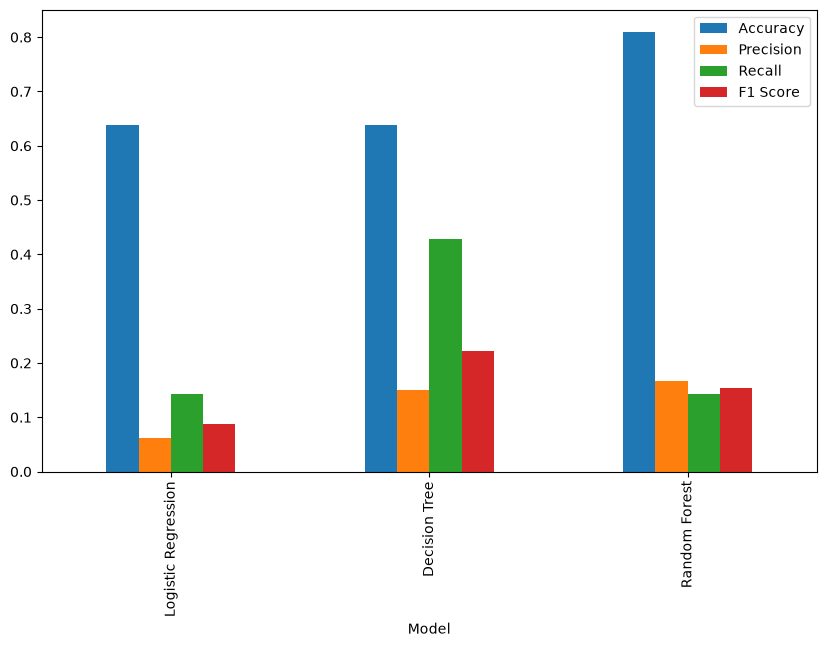

In [14]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

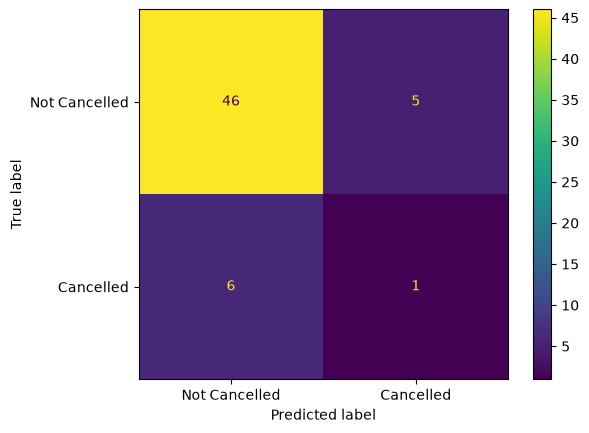

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Not Cancelled", "Cancelled"]
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get importance values
importances = random_forest_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(15))

                              Feature  Importance
0               num__ticket_price_inr    0.133194
1           num__advance_booking_days    0.113379
2                 num__miles_redeemed    0.102861
4       num__competitor_avg_price_inr    0.088222
5                      num__nps_score    0.071853
19  cat__booking_channel_Travel Agent    0.024868
3             num__lounge_access_used    0.018891
9                  cat__route_CCU-HYD    0.016441
11                 cat__route_DEL-BOM    0.016202
6                  cat__route_BLR-MAA    0.016127
24         cat__traveler_type_Leisure    0.015392
17    cat__booking_channel_Mobile App    0.014832
28    cat__flight_load_factor_pct_58%    0.013835
8                  cat__route_BOM-CCU    0.013722
64    cat__flight_load_factor_pct_94%    0.012692


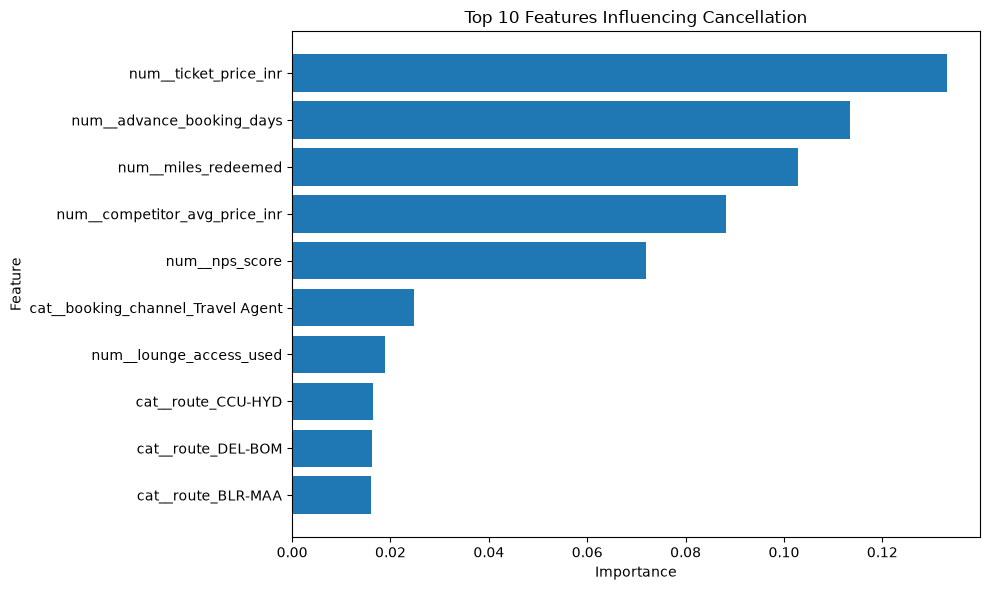

In [20]:
import matplotlib.pyplot as plt
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Cancellation")
plt.tight_layout()
plt.show()